# Decision Tree Classifier with Employee Attrition Dataset

In this notebook, we will build a decision tree classifier using the scikit-learn library. We will use a hypothetical employee attrition dataset for this example.

## Import Libraries

First, import the necessary libraries.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load and Explore the Dataset

Load `employee_attrition_small.csv` and explore its contents.

In [2]:
emp_df = pd.read_csv('employee_attrition_small.csv')
emp_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,EducationField,Gender,HourlyRate,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,TotalWorkingYears
0,41,Yes,Travel_Rarely,1102,Sales,Life Sciences,Female,94,Sales Executive,4,Single,5993,19479,8,Yes,8
1,49,No,Travel_Frequently,279,Research & Development,Life Sciences,Male,61,Research Scientist,2,Married,5130,24907,1,No,10
2,37,Yes,Travel_Rarely,1373,Research & Development,Other,Male,92,Laboratory Technician,3,Single,2090,2396,6,Yes,7
3,33,No,Travel_Frequently,1392,Research & Development,Life Sciences,Female,56,Research Scientist,3,Married,2909,23159,1,Yes,8
4,27,No,Travel_Rarely,591,Research & Development,Medical,Male,40,Laboratory Technician,2,Married,3468,16632,9,No,6


## Preprocess the Data

Convert categorical text columns to numbers using `LabelEncoder`. Print the encoding mapping for each column so you know which numbers to use when predicting.

> **Hint:** `JobSatisfaction` is already numeric (1–4) — leave it as-is.

In [23]:
X = emp_df.drop(columns = ['JobSatisfaction']).copy()
y = emp_df['JobSatisfaction'].copy()

# Store column headers to map in arr
map_headers = [
    'Attrition',
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

for h in map_headers:
    le = LabelEncoder()
    X[h] = le.fit_transform(X[h])
    print(f"\n{h} mapping:\n{dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded feature matrix:\n{X.head()}")


Attrition mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}

BusinessTravel mapping:
{'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}

Department mapping:
{'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}

EducationField mapping:
{'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}

Gender mapping:
{'Female': np.int64(0), 'Male': np.int64(1)}

JobRole mapping:
{'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': np.int64(7), 'Sales Representative': np.int64(8)}

MaritalStatus mapping:
{'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}

OverTime mapping:
{'No'

## Split the Dataset

Split into training and test sets using `test_size=0.2` and `random_state=42`.

In [30]:
# X = all feature columns (drop the Attrition column)
# y = Attrition column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 1176
Test set size: 294


## Train the Decision Tree Model

> **Note:** Keep `max_depth` no greater than 3 to avoid an unreadable tree.

In [34]:
# Create and train the decision tree classifier
dtc = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 3,
    random_state = 42
)

# Predict on the test set
dtc.fit(X_train, y_train)
y_test_pred = dtc.predict(X_test)

# Print accuracy
# test_accuracy = accuracy_score(y_test, y_test_pred)
# print(f"Test Accuracy: {test_accuracy:.2f}")

# results = X_test.copy()
# results['Actual'] = y_test.values
# results['Predicted'] = y_test_pred
# print(f"\nTest set predictions:\n{results.head()}")

Test Accuracy: 0.31

Test set predictions:
      Age  Attrition  BusinessTravel  DailyRate  Department  EducationField  \
594    29          0               2       1252           1               1   
974    27          0               1        793           2               1   
1005   29          0               2        332           0               4   
100    37          1               2        807           0               0   
888    35          0               0       1212           2               2   

      Gender  HourlyRate  JobRole  MaritalStatus  MonthlyIncome  MonthlyRate  \
594        1          81        6              1           2700        23779   
974        1          43        7              2           5071        20392   
1005       1          51        1              2           7988         9769   
100        1          63        1              0           2073        23648   
888        0          78        7              1          10377        13755   

 

## Evaluate the Model

Print the accuracy score and plot a confusion matrix.

Think about which type of error matters more here: a false negative (employee leaves but model predicted they would stay) or a false positive (employee stays but model predicted they would leave)?


Accuracy: 0.31


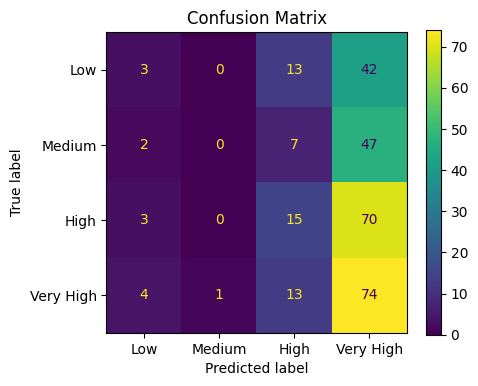

In [40]:
# Define y-axis labels
label_names = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

# print("Predicted:", [label_names[p] for p in y_test_pred])
# print("Actual:   ", [label_names[a] for a in y_test.values])
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred):.2f}")

# Build confusion matrix over all 4 classes
cm = confusion_matrix(
    y_test, 
    y_test_pred, 
    labels=[1, 2, 3, 4]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels = label_names.values()
)

disp.plot(ax = ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Visualize the Decision Tree

Use `plot_tree` from `sklearn.tree` to visualize the trained model.

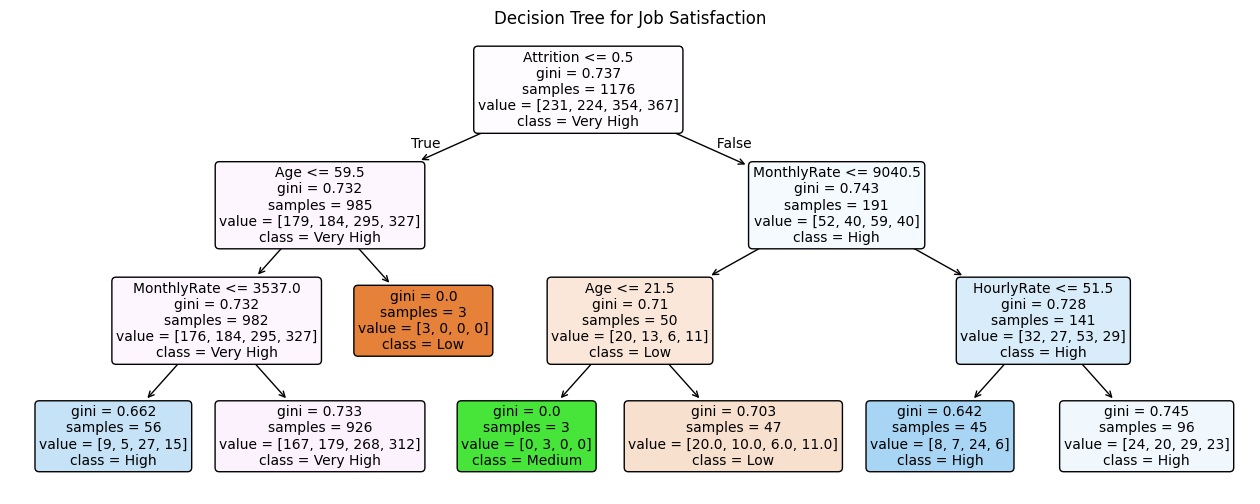

In [47]:
plt.figure(figsize = (16, 6))

plot_tree(
    dtc,
    feature_names = X.columns,
    class_names = list(label_names.values()),
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title('Decision Tree for Job Satisfaction')
plt.show()

## Predict for a New Employee

Use the encoding mappings you printed above to build a one-row DataFrame and predict whether that employee will leave.

In [56]:
new_emp = pd.DataFrame([{
    'Age': 35,
    'Attrition': 0,                 # No
    'BusinessTravel': 2,            # Travel_Rarely
    'DailyRate': 850,
    'Department': 1,                # Research & Development
    'EducationField': 3,            # Medical
    'Gender': 0,                    # Female
    'HourlyRate': 75,
    'JobRole': 6,                   # Research Scientist
    'MaritalStatus': 1,             # Married
    'MonthlyIncome': 5200,
    'MonthlyRate': 18000,
    'NumCompaniesWorked': 4,
    'OverTime': 0,                  # No
    'TotalWorkingYears': 11
}])

pred = dtc.predict(new_emp)[0]

display(new_emp)
print('Predicted outcome for new applicant''s Job Satisfaction:', pred, label_names[4])

,Age,Attrition,BusinessTravel,DailyRate,Department,EducationField,Gender,HourlyRate,JobRole,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,TotalWorkingYears
0,35,0,2,850,1,3,0,75,6,1,5200,18000,4,0,11


Predicted outcome for new applicants Job Satisfaction: 4 Very High
